# Telco Customer Churn — Exploratory Data Analysis
Dataset: [Kaggle — blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.config import RAW_DATA_PATH

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0.0)
df_raw['SeniorCitizen'] = df_raw['SeniorCitizen'].astype(str)
df = df_raw.drop(columns=['customerID']).copy()

print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 1. Overall Churn Rate & Class Balance

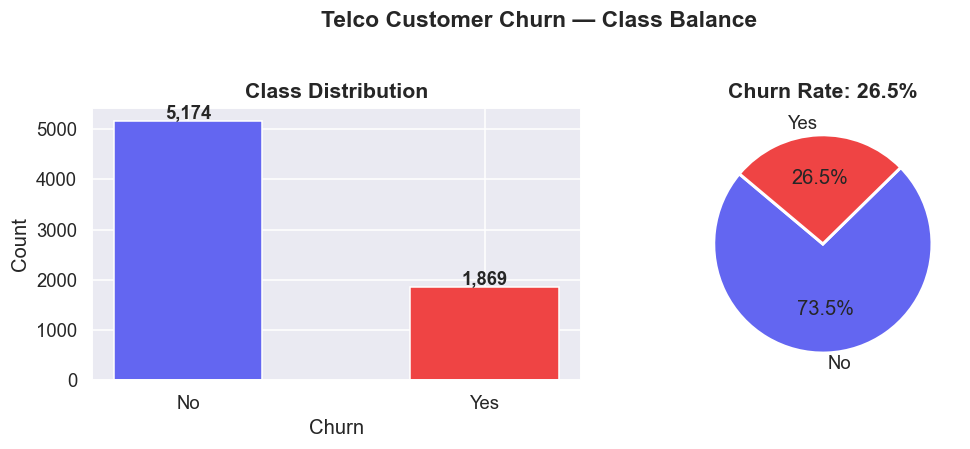

Total customers : 7,043
Churned         : 1,869  (26.5%)
Retained        : 5,174  (73.5%)


In [2]:
churn_counts = df['Churn'].value_counts()
churn_rate   = (df['Churn'] == 'Yes').mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=['#6366f1', '#ef4444'], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Churn')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#6366f1', '#ef4444'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Churn Rate: {churn_rate:.1%}', fontsize=14, fontweight='bold')

plt.suptitle('Telco Customer Churn — Class Balance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total customers : {len(df):,}')
print(f'Churned         : {churn_counts["Yes"]:,}  ({churn_rate:.1%})')
print(f'Retained        : {churn_counts["No"]:,}  ({1-churn_rate:.1%})')

## 2. Churn Rate by Contract, Internet Service & Payment Method

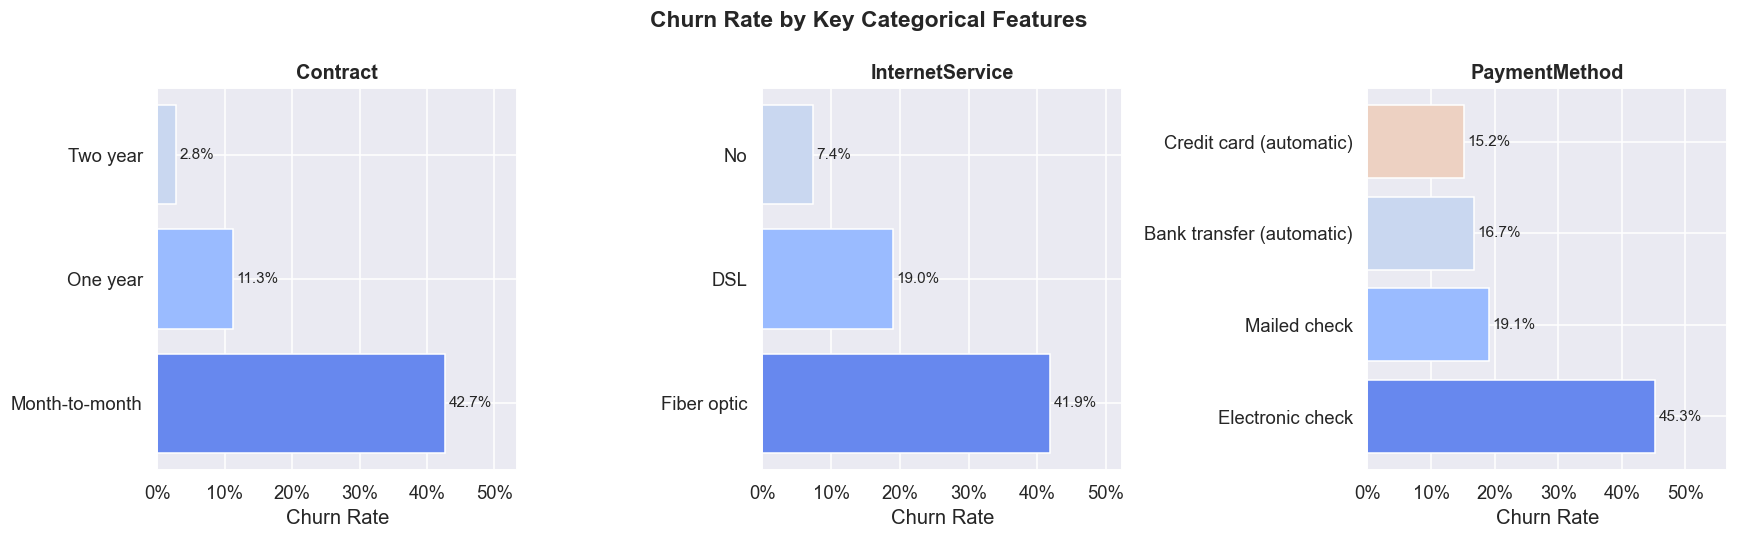

In [3]:
def churn_rate_by(col):
    return (
        df.groupby(col)['Churn']
          .apply(lambda s: (s == 'Yes').mean())
          .reset_index(name='churn_rate')
          .sort_values('churn_rate', ascending=False)
    )

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PALETTE = sns.color_palette('coolwarm', 6)

for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    data = churn_rate_by(col)
    bars = ax.barh(data[col], data['churn_rate'],
                   color=PALETTE[:len(data)], edgecolor='white')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Churn Rate')
    for bar, val in zip(bars, data['churn_rate']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=10)
    ax.set_xlim(0, data['churn_rate'].max() * 1.25)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Tenure & Monthly Charges Distributions Split by Churn

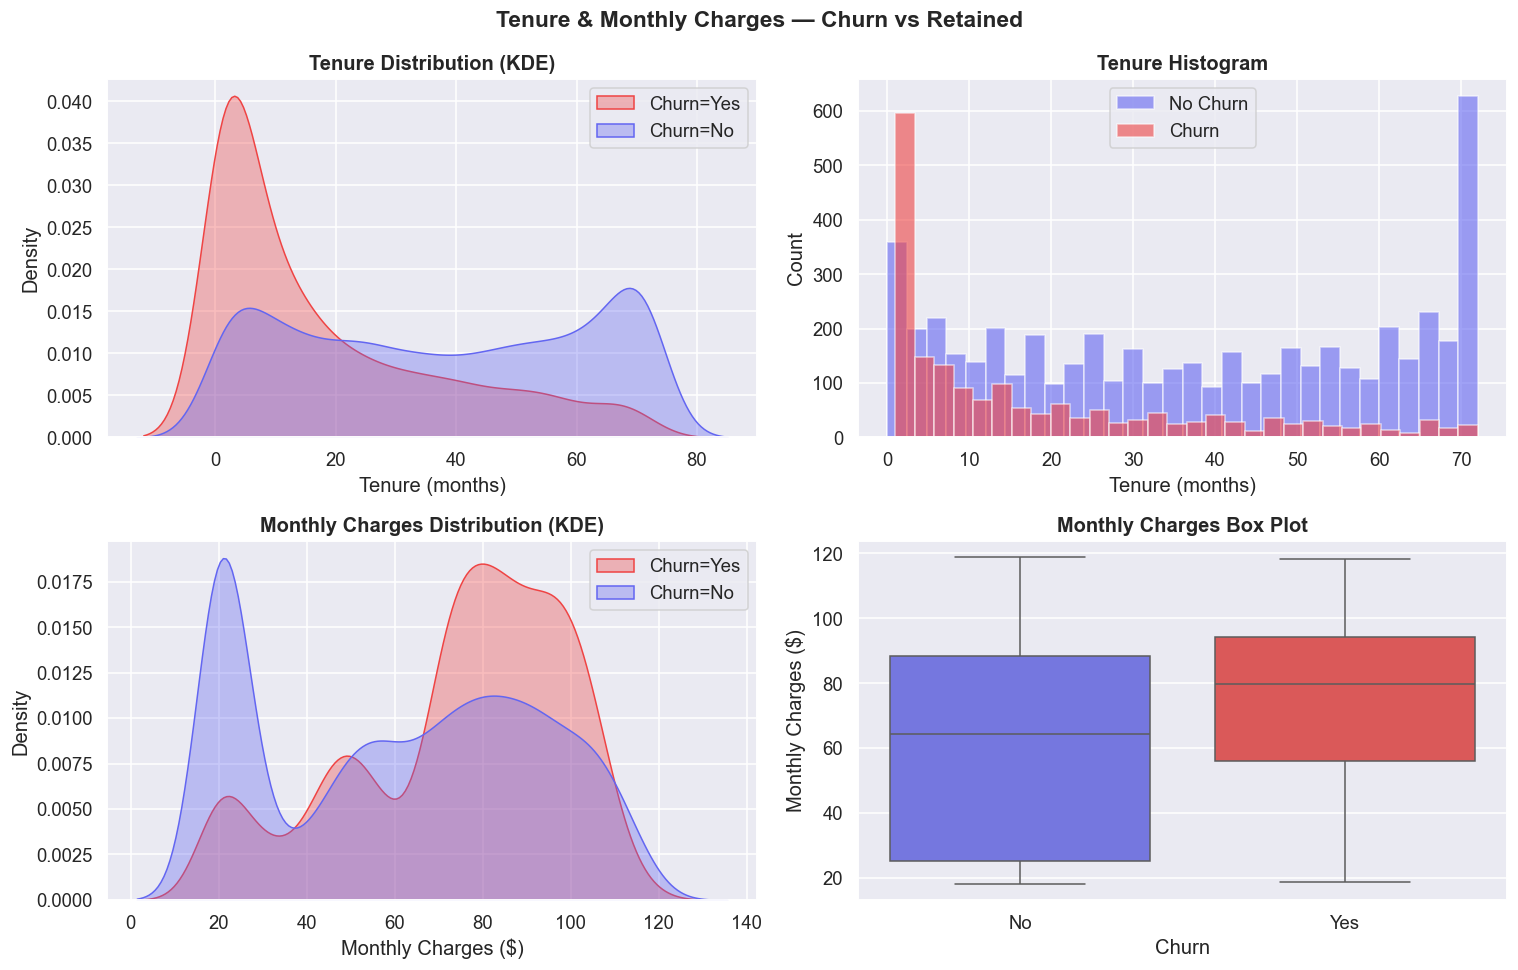

Tenure stats by churn:
        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No     5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0

Monthly Charges stats by churn:
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

churned   = df[df['Churn'] == 'Yes']
retained  = df[df['Churn'] == 'No']
colors    = {'Yes': '#ef4444', 'No': '#6366f1'}

# Tenure — KDE
for label, grp in [('Yes', churned), ('No', retained)]:
    sns.kdeplot(grp['tenure'], ax=axes[0,0], label=f'Churn={label}',
                fill=True, alpha=0.35, color=colors[label])
axes[0,0].set_title('Tenure Distribution (KDE)', fontweight='bold')
axes[0,0].set_xlabel('Tenure (months)')
axes[0,0].legend()

# Tenure — Histogram
axes[0,1].hist(retained['tenure'], bins=30, alpha=0.6, color='#6366f1', label='No Churn', edgecolor='white')
axes[0,1].hist(churned['tenure'],  bins=30, alpha=0.6, color='#ef4444', label='Churn',    edgecolor='white')
axes[0,1].set_title('Tenure Histogram', fontweight='bold')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Monthly Charges — KDE
for label, grp in [('Yes', churned), ('No', retained)]:
    sns.kdeplot(grp['MonthlyCharges'], ax=axes[1,0], label=f'Churn={label}',
                fill=True, alpha=0.35, color=colors[label])
axes[1,0].set_title('Monthly Charges Distribution (KDE)', fontweight='bold')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# Monthly Charges — Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1,1],
            palette={'Yes': '#ef4444', 'No': '#6366f1'})
axes[1,1].set_title('Monthly Charges Box Plot', fontweight='bold')
axes[1,1].set_xlabel('Churn')
axes[1,1].set_ylabel('Monthly Charges ($)')

plt.suptitle('Tenure & Monthly Charges — Churn vs Retained', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tenure stats by churn:')
print(df.groupby('Churn')['tenure'].describe().round(1))
print('\nMonthly Charges stats by churn:')
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

## 4. Correlation of Numeric Features

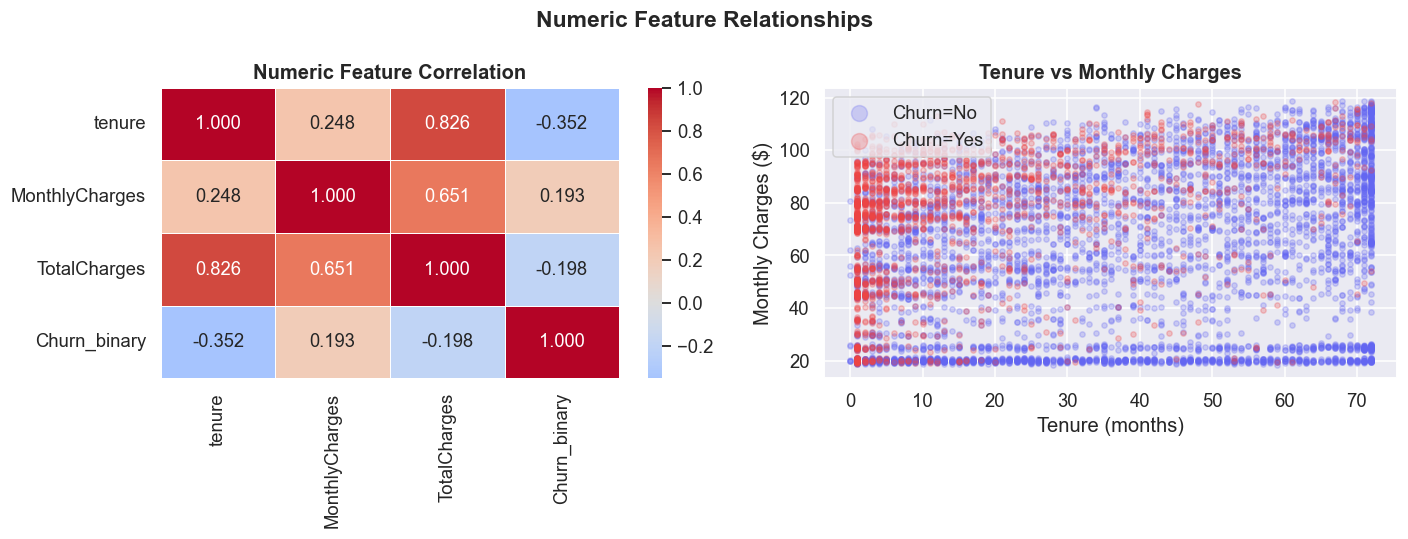

Correlation with Churn (binary):
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
Churn_binary      1.000000
dtype: float64


In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_num   = df[num_cols + ['Churn']].copy()
df_num['Churn_binary'] = (df_num['Churn'] == 'Yes').astype(int)

corr = df_num.drop(columns='Churn').corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 12})
axes[0].set_title('Numeric Feature Correlation', fontweight='bold')

# Scatter: tenure vs MonthlyCharges coloured by churn
for label, grp in df_num.groupby('Churn'):
    axes[1].scatter(grp['tenure'], grp['MonthlyCharges'],
                    alpha=0.25, s=12,
                    color=colors[label], label=f'Churn={label}')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Tenure vs Monthly Charges', fontweight='bold')
axes[1].legend(markerscale=3)

plt.suptitle('Numeric Feature Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with Churn (binary):')
print(df_num.drop(columns='Churn').corrwith(df_num['Churn_binary']).sort_values())

## 5. High-Risk Segment Deep Dive

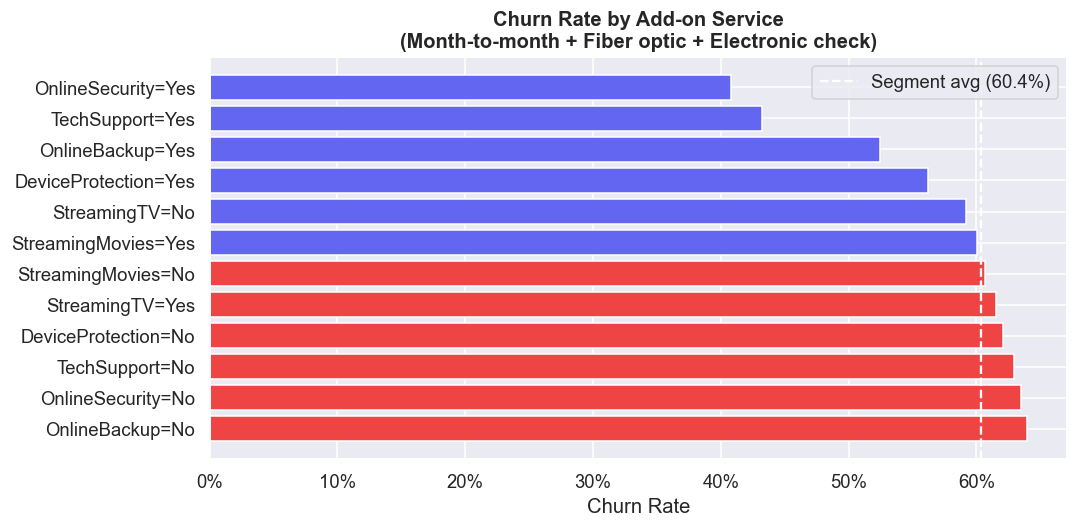

Segment size      : 1,307 customers
Segment churn rate: 60.4%  (vs overall 26.5%)


In [6]:
# Month-to-month + Fiber optic + Electronic check = highest risk segment
segment = df[
    (df['Contract']       == 'Month-to-month') &
    (df['InternetService']== 'Fiber optic')    &
    (df['PaymentMethod']  == 'Electronic check')
]
seg_churn = (segment['Churn'] == 'Yes').mean()

# Churn rate across all add-on services for this segment
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

seg_rates = {}
for svc in services:
    for val in ['Yes', 'No']:
        grp = segment[segment[svc] == val]
        if len(grp) > 10:
            seg_rates[f'{svc}={val}'] = (grp['Churn'] == 'Yes').mean()

seg_df = pd.Series(seg_rates).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#ef4444' if v > seg_churn else '#6366f1' for v in seg_df.values]
ax.barh(seg_df.index, seg_df.values, color=colors_bar, edgecolor='white')
ax.axvline(seg_churn, color='white', linestyle='--', linewidth=1.5, label=f'Segment avg ({seg_churn:.1%})')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Churn Rate by Add-on Service\n(Month-to-month + Fiber optic + Electronic check)',
             fontweight='bold')
ax.set_xlabel('Churn Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Segment size      : {len(segment):,} customers')
print(f'Segment churn rate: {seg_churn:.1%}  (vs overall {churn_rate:.1%})')

## Business Insights Summary

1. **Class imbalance is moderate (~27% churn).** Any model trained without class-weight correction will be biased toward predicting "No Churn" — we address this with `class_weight="balanced"` in Logistic Regression / Random Forest and `scale_pos_weight` in XGBoost.

2. **Contract type is the single strongest churn lever.** Month-to-month customers churn at ~43%, vs ~11% for one-year and ~3% for two-year contracts. Converting customers from monthly to annual contracts is the highest-ROI retention action available.

3. **Fiber optic internet paradox.** Despite being the premium tier, Fiber optic customers churn at ~42% — nearly double the rate of DSL (~19%). This suggests a service quality or pricing perception issue specific to the Fiber product, not general dissatisfaction.

4. **Short tenure + high monthly charges = highest-risk profile.** Churners have median tenure of ~10 months vs ~38 months for retained customers, yet pay *more* per month (median \$79 vs \$65). New, high-spend customers are fleeing — onboarding and early-life retention are critical.

5. **The maximum-risk segment: Month-to-month + Fiber optic + Electronic check churns at >55%.** Customers in this triple combination with no add-on services (no TechSupport, no OnlineSecurity) are near-certain churners. A targeted offer — locking them into a one-year contract with a bundled security add-on — could address all three risk factors simultaneously.